# Sources & Spectra

This tutorials is designed to give an overview of both the `Source` and `Spectrum` classes within dLux.

In [1]:
# Basic imports
import jax.numpy as np
import jax.random as jr

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72

First lets whip up an optical system that we can use to propagate the sources through.

In [2]:
# Define our wavefront properties
wf_npix = 512  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Construct a simple circular aperture
coords = dlu.pixel_coords(wf_npix, diameter)
aperture = dlu.circle(coords, 0.5 * diameter)

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds
oversample = 3  # Oversampling factor for the PSF

# Define the optical layers
layers = [('aperture', dl.layers.Optic(aperture, normalise=True))]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npix, diameter, layers, psf_npix, psf_pixel_scale, oversample
)

## Overview

The `Source` and `Spectrum` classes in dLux work in tandem, with all `Source` objects containing a `Spectrum` object. There are only two `Spectrum` classes implemented in dLux:

1. `Spectrum` is a simple array-based spectrum, contating `wavelengths` and `weights`.
2. `PolySpectrum` is a simple polynomial spectrum, containing `wavelengths` and `coefficients`.

In general users will not need to intract with the `Spectrum` objects directly, as they are automatically instatiated when creating a `Source` object. Lets take a look at the various different `Source` classes implemented in dLux.

1. `PointSource`
4. `ResolvedSource`
3. `BinarySource`
5. `PointResolvedSource`
2. `PointSources`
6. `Scene`

They all have a similar interface, having both a `.normalise` and `.model` method. The `.normalise` method takes no inputs and normalises the source and spectrum, which is important during optimisation since the updates during that process can not guarantee that the source remains normalised. The model method has the following signature `.model(optical_system, return_wf=False, return_psf=False)`, mirroring the `OpticalSystem.model` method. The `return_wf` and `return_psf` flags are used to determine what object is returned. If both are `False`, the returned psf is an array, if `return_wf` is `True` the returned psf is a `Wavefront` object, and if `return_psf` is `True` the returned psf is a `PSF` object.

Ands that about all there is to the `Source` objects! So lets jump in and have a look at these classes.

### Initialising the Spectrum

`Spectrum` objects can be initialised from the `Source` objects in two ways, either by passing in a `wavelengths` and (optional) `weights` array, or by passing in a `Spectrum` object directly. If a `Spectrum` object is passed in, the `wavelengths` and `weights` arrays are ignored. If only a `wavelengths` array is passed in, the `weights` array is initialised to be an array of ones. If both a `wavelengths` and `weights` array are passed in, the `weights` array is normalised to sum to one.

## PointSource

The `PointSource` class is very straightforwards with three attributes:

1. `position` - the position of the source in the sky, in radians.
2. `flux` - the flux of the source, in photons.
3. `spectrum` - the spectrum of the source.

Lets create one and model it through an optical system. We will also return the `PSF` object so we can examine both the oversampled and downsampled psfs.

In [3]:
# Define the source properties
flux = 1e4
position = dlu.arcsec2rad(np.array([1, 0]))
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)

# Construct the source object and examine it
point = dl.PointSource(wavelengths, position, flux)
print(point)

PointSource(
  spectrum=Spectrum(wavelengths=f32[10], weights=f32[10]),
  position=f32[2],
  flux=10000.0
)


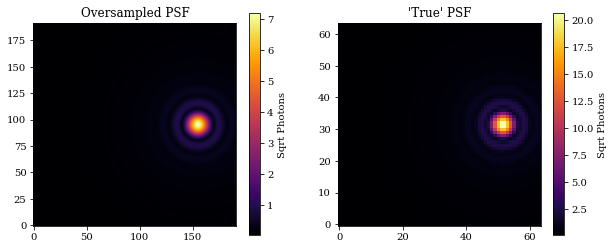

In [4]:
# Model the source and examine the PSF
psf_oversample = point.model(optics)
PSF = point.model(optics, return_psf=True).downsample(oversample)

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Oversampled PSF")
plt.imshow(psf_oversample**0.5)
plt.colorbar(label='Sqrt Photons')

plt.subplot(1, 2, 2)
plt.title("'True' PSF")
plt.imshow(PSF.data**0.5)
plt.colorbar(label='Sqrt Photons')
plt.show()

## ResolvedSource

The resolved source operates very similarly to the `PointSource` class, only adding the `distribution` attribute.

1. `position` - the position of the source in the sky, in radians.
2. `flux` - the flux of the source, in photons.
3. `spectrum` - the spectrum of the source.
4. `distribution` - the distribution of the source.

Lets create one and model it through an optical system.

In [5]:
# Define the source properties
flux = 1e4
position = np.zeros(2)
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)
distribution = np.ones((10, 10))

# Construct the source object and examine it
resolved = dl.ResolvedSource(wavelengths, position, flux, distribution)
print(resolved)

# Model the source
psf = resolved.model(optics)

ResolvedSource(
  spectrum=Spectrum(wavelengths=f32[10], weights=f32[10]),
  position=f32[2],
  flux=10000.0,
  distribution=f32[10,10]
)


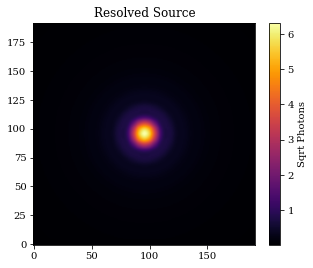

In [6]:
# Plot
plt.figure(figsize=(5, 4))
plt.title("Resolved Source")
plt.imshow(psf**0.5)
plt.colorbar(label='Sqrt Photons')
plt.show()

## BinarySource

The `BinarySource` class parametrises two point sources with 6 parameters:

1. `position` - the mean position of the source in the sky, in radians.
2. `separation` - the separation of the two sources, in radians.
3. `position_angle` - the position angle of the two sources, in radians.
4. `mean_flux` - the mean flux of the sources, in photons.
5. `contrast` - the contrast of the two sources, in photons.
6. `spectrum` - the spectrum of the sources.

We can also pass in an array of `weights` in order to give them _different_ spectra. Lets create one and model it through an optical system.

In [7]:
# Define the source properties
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)
weights = np.array([np.linspace(0.5, 1.5, 10), np.linspace(1.5, 0.5, 10)])

# Construct the source object and examine it
binary = dl.BinarySource(
    wavelengths,
    mean_flux=1e4,
    contrast=5,
    weights=weights,
    separation=dlu.arcsec2rad(1),
)
print(binary)

# Model the source
psf = binary.model(optics)

BinarySource(
  spectrum=Spectrum(wavelengths=f32[10], weights=f32[2,10]),
  position=f32[2],
  mean_flux=10000.0,
  separation=4.84813681109536e-06,
  position_angle=1.5707963267948966,
  contrast=5.0
)


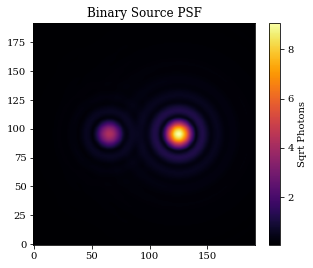

In [8]:
# Plot
plt.figure(figsize=(5, 4))
plt.title("Binary Source PSF")
plt.imshow(psf**0.5)
plt.colorbar(label='Sqrt Photons')
plt.show()

## PointResolvedSource

The PointResolved source is a combination of the `PointSource` and `ResolvedSource` classes, allowing for a point source _and_ a resolved component to be modelled simultaneously. It has the following attributes:

1. `position` - the position of the source in the sky, in radians.
2. `flux` - the mean flux of the point and resolved source, in photons.
5. `contrast` - the contrast of the two sources, in photons.
3. `spectrum` - the spectrum of the source.
4. `distribution` - the distribution of the resolved source.

Lets create one and model it through an optical system.

In [9]:
# Define the source properties
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)
distribution = np.ones((1, 100))

# Construct the source object and examine it
point_resolved = dl.PointResolvedSource(
    wavelengths, flux=1e6, contrast=5, distribution=distribution
)
print(point_resolved)

# Model the source
psf = point_resolved.model(optics)

PointResolvedSource(
  spectrum=Spectrum(wavelengths=f32[10], weights=f32[2,10]),
  position=f32[2],
  flux=1000000.0,
  distribution=f32[1,100],
  contrast=5.0
)


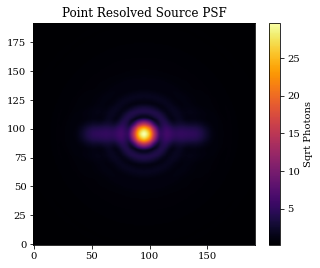

In [10]:
# Plot
plt.figure(figsize=(5, 4))
plt.title("Point Resolved Source PSF")
plt.imshow(psf**0.5)
plt.colorbar(label='Sqrt Photons')
plt.show()

## PointSources

The `PointSources` class is very similar to the `PointSource` class, simple expanding the first axes of all the `PointSource` attributes in order to model multiple point sources simultaneously. It has the following attributes:

1. `position` - the positions of the sources in the sky, in radians.
2. `flux` - the fluxes of the sources, in photons.
3. `spectrum` - the spectrum of the sources.

Lets create one and model it through an optical system.

In [11]:
wavelengths = 1e-6 * np.linspace(0.9, 1.1, 10)
dr = dlu.arcsec2rad(1.5)
positions = jr.uniform(jr.PRNGKey(0), (20, 2), minval=-dr, maxval=dr)
fluxes = jr.uniform(jr.PRNGKey(1), (20,), minval=1e3, maxval=1e4)

# Construct the source object and examine it
points = dl.PointSources(wavelengths, positions, fluxes)
print(points)

# Model the source
psf = points.model(optics)

PointSources(
  spectrum=Spectrum(wavelengths=f32[10], weights=f32[10]),
  position=f32[20,2],
  flux=f32[20]
)


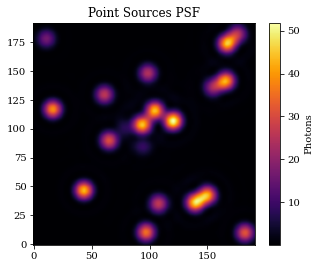

In [12]:
# Plot
plt.figure(figsize=(5, 4))
plt.title("Point Sources PSF")
plt.imshow(psf)
plt.colorbar(label='Photons')
plt.show()

## Scene

The `Scene` class is a simple container class for `Source` objects, allowing for multiple sources to be modelled simultaneously. It behaves similarly to optical systems in dLux, taking in a list of `Source` objects that are stored in a dictionary. Lets model a series of the sources we just created through an optical system.

In [13]:
# Define the sources
sources = [("resolved", point_resolved), ("points", points)]

# Construct the scene object and examine it
scene = dl.Scene(sources)
print(scene)

# Model the scene
psf = scene.model(optics)


Scene(
  sources={
    'resolved':
    PointResolvedSource(
      spectrum=Spectrum(wavelengths=f32[10], weights=f32[2,10]),
      position=f32[2],
      flux=1000000.0,
      distribution=f32[1,100],
      contrast=5.0
    ),
    'points':
    PointSources(
      spectrum=Spectrum(wavelengths=f32[10], weights=f32[10]),
      position=f32[20,2],
      flux=f32[20]
    )
  }
)


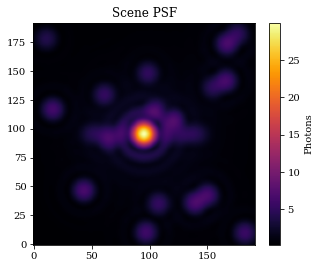

In [14]:
# Plot
plt.figure(figsize=(5, 4))
plt.title("Scene PSF")
plt.imshow(psf**0.5)
plt.colorbar(label='Photons')
plt.show()